# Dynamic Programming | Checkpoint 3
**Professor:** Andre Marques  

## Integrantes

| Nome Completo | RM |
|---|---|
| Giovana Gaspar Larocca | 564965 |
| Giovanna Lins Sayama | 565901 |
| Rayssa Luzia Portela Aquino | 562024 |


---

## Objetivo

Construir um sistema de rotas para metrô em três metrópoles — **Beijing**, **San Francisco** e **São Paulo** — modelando as redes como grafos ponderados e aplicando **recursão com memoização** para encontrar o caminho mais curto e o caminho mais longo simples entre estações.

---
## [1] Imports e Configurações Iniciais

In [ ]:
import time
import tracemalloc
import functools
import sys
import folium
import math
from IPython.display import display, HTML

try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

print(' Bibliotecas carregadas com sucesso!')
print(f'   Python {sys.version.split()[0]} | folium {folium.__version__}')

✅ Bibliotecas carregadas com sucesso!
   Python 3.12.3 | folium 0.20.0


---
## [2] Modelagem dos Grafos — Teoria e Código

### Escolha de Modelagem

Optamos por grafos **não-dirigidos** (bidirecional), pois as linhas de metrô nas três cidades permitem viagem nos dois sentidos nas mesmas vias. Cada aresta possui peso representando o **tempo médio de percurso em minutos** entre estações adjacentes.

**Estrutura:** `{ estação: [(vizinho, peso_base), ...] }`

Os pesos são tempo em minutos. O `fator_horario` será aplicado em tempo de execução dos algoritmos.

### Complexidade da Modelagem
- **Espaço:** O(V + E), onde V = vértices (estações) e E = arestas (conexões)
- As três cidades possuem ≥ 15 estações e múltiplos caminhos entre origem e destino

In [ ]:
# ============================================================
#  BEIJING — Linhas 1, 2, 4 e 10
#  Origem: Sihui East | Destino: Xizhimen
# ============================================================
grafo_beijing = {
    # Linha 1 (Leste → Oeste)
    "Sihui East":        [("Sihui", 2)],
    "Sihui":             [("Sihui East", 2), ("Guomao", 3)],
    "Guomao":            [("Sihui", 3), ("Yong'anli", 2)],
    "Yong'anli":         [("Guomao", 2), ("Jianguomen", 2)],
    "Jianguomen":        [("Yong'anli", 2), ("Dongdan", 2), ("Jianguomen_L2", 0)],  # transferência L2
    "Dongdan":           [("Jianguomen", 2), ("Wangfujing", 2)],
    "Wangfujing":        [("Dongdan", 2), ("Tiananmen East", 2)],
    "Tiananmen East":    [("Wangfujing", 2), ("Tiananmen West", 2)],
    "Tiananmen West":    [("Tiananmen East", 2), ("Xidan", 2)],
    "Xidan":             [("Tiananmen West", 2), ("Fuxingmen", 2), ("Xidan_L4", 0)],  # transferência L4
    "Fuxingmen":         [("Xidan", 2), ("Muxidi", 3), ("Fuxingmen_L2", 0)],
    "Muxidi":            [("Fuxingmen", 3), ("Junshi Bowuguan", 2)],
    "Junshi Bowuguan":   [("Muxidi", 2), ("Gongzhufen", 3)],
    "Gongzhufen":        [("Junshi Bowuguan", 3), ("Wanshoulu", 2)],
    "Wanshoulu":         [("Gongzhufen", 2), ("Wukesong", 3)],
    "Wukesong":          [("Wanshoulu", 3)],

    # Linha 2 (circular) — estações relevantes
    "Jianguomen_L2":     [("Jianguomen", 0), ("Chaoyangmen", 3), ("Fuxingmen_L2", 8)],
    "Chaoyangmen":       [("Jianguomen_L2", 3), ("Dongzhimen", 4)],
    "Dongzhimen":        [("Chaoyangmen", 4), ("Yonghegong", 3)],
    "Yonghegong":        [("Dongzhimen", 3), ("Gulou Dajie", 3)],
    "Gulou Dajie":       [("Yonghegong", 3), ("Jishuitan", 4)],
    "Jishuitan":         [("Gulou Dajie", 4), ("Xizhimen_L2", 3)],
    "Xizhimen_L2":       [("Jishuitan", 3), ("Xizhimen", 0), ("Fuxingmen_L2", 5)],
    "Fuxingmen_L2":      [("Fuxingmen", 0), ("Jianguomen_L2", 8), ("Xizhimen_L2", 5)],

    # Linha 4 — conecta com L1 em Xidan e sobe ao norte
    "Xidan_L4":          [("Xidan", 0), ("Xisi", 3), ("Linglong Road", 5)],
    "Xisi":              [("Xidan_L4", 3), ("Pinganli", 3)],
    "Pinganli":          [("Xisi", 3), ("Xizhimen_L4", 4)],
    "Xizhimen_L4":       [("Pinganli", 4), ("Xizhimen", 0)],
    "Linglong Road":     [("Xidan_L4", 5)],

    # Destino final
    "Xizhimen":          [("Xizhimen_L2", 0), ("Xizhimen_L4", 0)],
}

# Coordenadas geográficas para visualização
coords_beijing = {
    "Sihui East":       (39.9043, 116.5045),
    "Sihui":            (39.9043, 116.4920),
    "Guomao":           (39.9083, 116.4610),
    "Yong'anli":        (39.9083, 116.4470),
    "Jianguomen":       (39.9083, 116.4330),
    "Dongdan":          (39.9083, 116.4180),
    "Wangfujing":       (39.9083, 116.4080),
    "Tiananmen East":   (39.9083, 116.3980),
    "Tiananmen West":   (39.9083, 116.3880),
    "Xidan":            (39.9083, 116.3660),
    "Fuxingmen":        (39.9083, 116.3530),
    "Muxidi":           (39.9083, 116.3360),
    "Junshi Bowuguan":  (39.9083, 116.3200),
    "Gongzhufen":       (39.9083, 116.3050),
    "Wanshoulu":        (39.9083, 116.2900),
    "Wukesong":         (39.9083, 116.2730),
    "Jianguomen_L2":    (39.9140, 116.4330),
    "Chaoyangmen":      (39.9230, 116.4420),
    "Dongzhimen":       (39.9340, 116.4480),
    "Yonghegong":       (39.9470, 116.4280),
    "Gulou Dajie":      (39.9470, 116.4010),
    "Jishuitan":        (39.9470, 116.3730),
    "Xizhimen_L2":      (39.9440, 116.3500),
    "Fuxingmen_L2":     (39.9140, 116.3530),
    "Xidan_L4":         (39.9000, 116.3660),
    "Xisi":             (39.9230, 116.3660),
    "Pinganli":         (39.9350, 116.3660),
    "Xizhimen_L4":      (39.9440, 116.3480),
    "Linglong Road":    (39.8700, 116.3660),
    "Xizhimen":         (39.9440, 116.3490),
}

print(f'🇨🇳 Beijing: {len(grafo_beijing)} estações | '
      f'Origem: Sihui East → Destino: Xizhimen')

🇨🇳 Beijing: 30 estações | Origem: Sihui East → Destino: Xizhimen


In [ ]:
# ============================================================
#  SAN FRANCISCO — Rede BART
#  Origem: Dublin/Pleasanton | Destino: Daly City
# ============================================================
grafo_sf = {
    # Linha Azul (Blue) — Dublin/Pleasanton → Daly City
    "Dublin/Pleasanton":  [("West Dublin", 4)],
    "West Dublin":        [("Dublin/Pleasanton", 4), ("Castro Valley", 7)],
    "Castro Valley":      [("West Dublin", 7), ("Bay Fair", 6)],
    "Bay Fair":           [("Castro Valley", 6), ("San Leandro", 5), ("South Hayward", 5)],
    "South Hayward":      [("Bay Fair", 5), ("Hayward", 4)],
    "Hayward":            [("South Hayward", 4), ("Union City", 5)],
    "Union City":         [("Hayward", 5), ("Fremont", 6)],
    "Fremont":            [("Union City", 6)],
    "San Leandro":        [("Bay Fair", 5), ("Fruitvale", 6)],
    "Fruitvale":          [("San Leandro", 6), ("Coliseum", 4)],
    "Coliseum":           [("Fruitvale", 4), ("Lake Merritt", 6)],
    "Lake Merritt":       [("Coliseum", 6), ("12th St Oakland", 3)],
    "12th St Oakland":    [("Lake Merritt", 3), ("19th St Oakland", 2)],
    "19th St Oakland":    [("12th St Oakland", 2), ("MacArthur", 4)],
    "MacArthur":          [("19th St Oakland", 4), ("Rockridge", 5), ("Ashby", 5)],
    "Rockridge":          [("MacArthur", 5), ("Orinda", 7)],
    "Orinda":             [("Rockridge", 7), ("Lafayette", 5)],
    "Lafayette":          [("Orinda", 5), ("Walnut Creek", 5)],
    "Walnut Creek":       [("Lafayette", 5), ("Pleasant Hill", 4)],
    "Pleasant Hill":      [("Walnut Creek", 4), ("Concord", 5)],
    "Concord":            [("Pleasant Hill", 5), ("North Concord", 4)],
    "North Concord":      [("Concord", 4), ("Pittsburg", 8)],
    "Pittsburg":          [("North Concord", 8)],
    "Ashby":              [("MacArthur", 5), ("Downtown Berkeley", 4)],
    "Downtown Berkeley":  [("Ashby", 4), ("North Berkeley", 3)],
    "North Berkeley":     [("Downtown Berkeley", 3), ("El Cerrito Plaza", 4)],
    "El Cerrito Plaza":   [("North Berkeley", 4), ("El Cerrito del Norte", 3)],
    "El Cerrito del Norte": [("El Cerrito Plaza", 3), ("Richmond", 4)],
    "Richmond":           [("El Cerrito del Norte", 4)],
    # Crossing Bay
    "West Oakland":       [("12th St Oakland", 5), ("Embarcadero", 8)],
    "Embarcadero":        [("West Oakland", 8), ("Montgomery St", 2)],
    "Montgomery St":      [("Embarcadero", 2), ("Powell St", 2)],
    "Powell St":          [("Montgomery St", 2), ("Civic Center", 2)],
    "Civic Center":       [("Powell St", 2), ("16th St Mission", 3)],
    "16th St Mission":    [("Civic Center", 3), ("24th St Mission", 3)],
    "24th St Mission":    [("16th St Mission", 3), ("Glen Park", 4)],
    "Glen Park":          [("24th St Mission", 4), ("Balboa Park", 4)],
    "Balboa Park":        [("Glen Park", 4), ("Daly City", 4)],
    "Daly City":          [("Balboa Park", 4)],
}

# Adicionar West Oakland como atalho da L1 para SF
grafo_sf["12th St Oakland"].append(("West Oakland", 5))

coords_sf = {
    "Dublin/Pleasanton":    (37.7019, -121.8994),
    "West Dublin":          (37.6999, -121.9281),
    "Castro Valley":        (37.6927, -122.0757),
    "Bay Fair":             (37.6972, -122.1264),
    "South Hayward":        (37.6344, -122.0577),
    "Hayward":              (37.6700, -122.0886),
    "Union City":           (37.5908, -122.0175),
    "Fremont":              (37.5572, -121.9762),
    "San Leandro":          (37.7022, -122.1609),
    "Fruitvale":            (37.7746, -122.2243),
    "Coliseum":             (37.7540, -122.1978),
    "Lake Merritt":         (37.7977, -122.2651),
    "12th St Oakland":      (37.8033, -122.2720),
    "19th St Oakland":      (37.8082, -122.2690),
    "MacArthur":            (37.8285, -122.2668),
    "Rockridge":            (37.8444, -122.2524),
    "Orinda":               (37.8783, -122.1830),
    "Lafayette":            (37.8937, -122.1247),
    "Walnut Creek":         (37.9057, -122.0675),
    "Pleasant Hill":        (37.9281, -122.0561),
    "Concord":              (37.9736, -122.0291),
    "North Concord":        (37.9940, -122.0211),
    "Pittsburg":            (37.9994, -121.9457),
    "Ashby":                (37.8529, -122.2700),
    "Downtown Berkeley":    (37.8700, -122.2680),
    "North Berkeley":       (37.8742, -122.2834),
    "El Cerrito Plaza":     (37.9017, -122.2990),
    "El Cerrito del Norte": (37.9247, -122.3168),
    "Richmond":             (37.9368, -122.3531),
    "West Oakland":         (37.8048, -122.2954),
    "Embarcadero":          (37.7929, -122.3966),
    "Montgomery St":        (37.7894, -122.4012),
    "Powell St":            (37.7844, -122.4083),
    "Civic Center":         (37.7796, -122.4139),
    "16th St Mission":      (37.7651, -122.4196),
    "24th St Mission":      (37.7524, -122.4183),
    "Glen Park":            (37.7329, -122.4337),
    "Balboa Park":          (37.7218, -122.4476),
    "Daly City":            (37.7060, -122.4690),
}

print(f'🇺🇸 San Francisco: {len(grafo_sf)} estações | '
      f'Origem: Dublin/Pleasanton → Destino: Daly City')

🇺🇸 San Francisco: 39 estações | Origem: Dublin/Pleasanton → Destino: Daly City


In [ ]:
# ============================================================
#  SÃO PAULO — Metrô + CPTM
#  Origem: Tucuruvi (L1) | Destino: Capão Redondo (L5)
#  Rota obrigatória por pelo menos uma estação de integração
# ============================================================
grafo_sp = {
    # Linha 1 - Azul (Norte → Sul)
    "Tucuruvi":          [("Parada Inglesa", 3)],
    "Parada Inglesa":    [("Tucuruvi", 3), ("Jardim São Paulo", 3)],
    "Jardim São Paulo":  [("Parada Inglesa", 3), ("Carandiru", 3)],
    "Carandiru":         [("Jardim São Paulo", 3), ("Santana", 2)],
    "Santana":           [("Carandiru", 2), ("Portuguesa Tietê", 3)],
    "Portuguesa Tietê":  [("Santana", 3), ("Armênia", 3)],
    "Armênia":           [("Portuguesa Tietê", 3), ("Tiradentes", 3)],
    "Tiradentes":        [("Armênia", 3), ("Luz", 2)],
    # Luz — integração L1, L3 e CPTM
    "Luz":               [("Tiradentes", 2), ("São Bento", 2),
                          ("Palmeiras-Barra Funda", 6)],  # CPTM L7
    "São Bento":         [("Luz", 2), ("Sé", 2)],
    # Sé — maior integração (L1 + L3)
    "Sé":                [("São Bento", 2), ("Liberdade", 3),
                          ("Pedro II", 3), ("Sé_L3", 0)],
    "Liberdade":         [("Sé", 3), ("São Judas", 3)],
    "São Judas":         [("Liberdade", 3), ("Saúde", 3)],
    "Saúde":             [("São Judas", 3), ("Praça da Árvore", 3)],
    "Praça da Árvore":   [("Saúde", 3), ("Santo Amaro", 4)],
    "Santo Amaro":       [("Praça da Árvore", 4), ("João Dias", 3)],
    "João Dias":         [("Santo Amaro", 3), ("Santo André", 4)],
    "Santo André":       [("João Dias", 4)],

    # Linha 3 - Vermelha
    "Sé_L3":             [("Sé", 0), ("Pedro II", 3), ("República", 2)],
    "Pedro II":          [("Sé", 3), ("Sé_L3", 3)],
    "República":         [("Sé_L3", 2), ("Anhangabaú", 2)],
    "Anhangabaú":        [("República", 2), ("Palmeiras-Barra Funda", 5)],
    # Palmeiras-Barra Funda — integração L3, CPTM
    "Palmeiras-Barra Funda": [("Anhangabaú", 5), ("Luz", 6),
                               ("Marechal Deodoro", 3)],
    "Marechal Deodoro":  [("Palmeiras-Barra Funda", 3), ("Santa Cecília", 3)],
    "Santa Cecília":     [("Marechal Deodoro", 3), ("Consolação", 4)],
    "Consolação":        [("Santa Cecília", 4), ("Paulista", 3), ("Consolação_L2", 0)],

    # Linha 2 - Verde
    "Consolação_L2":     [("Consolação", 0), ("Paulista_L2", 3), ("Clínicas", 4)],
    "Paulista_L2":       [("Consolação_L2", 3), ("Trianon-MASP", 2)],
    "Trianon-MASP":      [("Paulista_L2", 2), ("Brigadeiro", 2)],
    "Brigadeiro":        [("Trianon-MASP", 2), ("Paraíso_L2", 3)],
    "Paraíso_L2":        [("Brigadeiro", 3), ("Paraíso_L1", 0)],
    "Paraíso_L1":        [("Paraíso_L2", 0), ("Ana Rosa", 3), ("Liberdade", 4)],
    "Ana Rosa":          [("Paraíso_L1", 3), ("Ana Rosa_L5", 0)],

    # Linha 5 - Lilás — integração em Ana Rosa com L2, chega a Capão Redondo
    "Ana Rosa_L5":       [("Ana Rosa", 0), ("Chácara Klabin", 4)],
    "Chácara Klabin":    [("Ana Rosa_L5", 4), ("Alto da Boa Vista", 5)],
    "Alto da Boa Vista": [("Chácara Klabin", 5), ("Borba Gato", 4)],
    "Borba Gato":        [("Alto da Boa Vista", 4), ("Brooklin", 4)],
    "Brooklin":          [("Borba Gato", 4), ("República do Líbano", 3)],
    "República do Líbano": [("Brooklin", 3), ("Eucaliptos", 3)],
    "Eucaliptos":        [("República do Líbano", 3), ("Moema", 3)],
    "Moema":             [("Eucaliptos", 3), ("AACD-Servidor", 3)],
    "AACD-Servidor":     [("Moema", 3), ("Hospital São Paulo", 3)],
    "Hospital São Paulo": [("AACD-Servidor", 3), ("Santa Cruz", 3)],
    "Santa Cruz":        [("Hospital São Paulo", 3), ("Paulista", 5)],
    "Paulista":          [("Santa Cruz", 5), ("Consolação", 3), ("Largo Treze", 5)],
    "Largo Treze":       [("Paulista", 5), ("Adolfo Pinheiro", 4)],
    "Adolfo Pinheiro":   [("Largo Treze", 4), ("Alto da Boa Vista", 4), ("Capão Redondo", 4)],
    "Clínicas":          [("Consolação_L2", 4), ("Sumaré", 3)],
    "Sumaré":            [("Clínicas", 3)],
    "Capão Redondo":     [("Adolfo Pinheiro", 4)],
}

coords_sp = {
    "Tucuruvi":            (-23.4758, -46.6147),
    "Parada Inglesa":      (-23.4883, -46.6190),
    "Jardim São Paulo":    (-23.5010, -46.6197),
    "Carandiru":           (-23.5100, -46.6218),
    "Santana":             (-23.5040, -46.6267),
    "Portuguesa Tietê":   (-23.5220, -46.6285),
    "Armênia":             (-23.5268, -46.6311),
    "Tiradentes":          (-23.5340, -46.6337),
    "Luz":                 (-23.5359, -46.6334),
    "São Bento":           (-23.5421, -46.6341),
    "Sé":                  (-23.5502, -46.6333),
    "Liberdade":           (-23.5592, -46.6325),
    "São Judas":           (-23.5752, -46.6268),
    "Saúde":               (-23.5875, -46.6285),
    "Praça da Árvore":     (-23.6012, -46.6298),
    "Santo Amaro":         (-23.6501, -46.7101),
    "João Dias":           (-23.6650, -46.7235),
    "Santo André":         (-23.6750, -46.7380),
    "Sé_L3":               (-23.5506, -46.6340),
    "Pedro II":            (-23.5457, -46.6255),
    "República":           (-23.5436, -46.6430),
    "Anhangabaú":          (-23.5438, -46.6430),
    "Palmeiras-Barra Funda": (-23.5256, -46.6651),
    "Marechal Deodoro":    (-23.5338, -46.6461),
    "Santa Cecília":       (-23.5352, -46.6531),
    "Consolação":          (-23.5564, -46.6610),
    "Consolação_L2":       (-23.5568, -46.6614),
    "Paulista_L2":         (-23.5615, -46.6555),
    "Trianon-MASP":        (-23.5649, -46.6531),
    "Brigadeiro":          (-23.5715, -46.6504),
    "Paraíso_L2":          (-23.5776, -46.6481),
    "Paraíso_L1":          (-23.5779, -46.6473),
    "Ana Rosa":            (-23.5874, -46.6450),
    "Ana Rosa_L5":         (-23.5876, -46.6454),
    "Chácara Klabin":      (-23.5998, -46.6380),
    "Alto da Boa Vista":   (-23.6095, -46.6614),
    "Borba Gato":          (-23.6181, -46.6812),
    "Brooklin":            (-23.6242, -46.6890),
    "República do Líbano": (-23.6280, -46.6950),
    "Eucaliptos":          (-23.6330, -46.7020),
    "Moema":               (-23.6013, -46.6721),
    "AACD-Servidor":       (-23.6065, -46.6810),
    "Hospital São Paulo":  (-23.6120, -46.6890),
    "Santa Cruz":          (-23.6017, -46.6454),
    "Paulista":            (-23.5617, -46.6559),
    "Largo Treze":         (-23.6600, -46.7204),
    "Adolfo Pinheiro":     (-23.6680, -46.7321),
    "Clínicas":            (-23.5574, -46.6700),
    "Sumaré":              (-23.5508, -46.6817),
    "Capão Redondo":       (-23.6713, -46.7745),
}

print(f'🇧🇷 São Paulo: {len(grafo_sp)} estações | '
      f'Origem: Tucuruvi → Destino: Capão Redondo')

🇧🇷 São Paulo: 50 estações | Origem: Tucuruvi → Destino: Capão Redondo


---
## [3] Fatores de Horário — Penalidades e Bônus

Os pesos das arestas são multiplicados por um fator dependendo do horário de partida:

| Faixa Horária | Fator | Justificativa |
|---|---|---|
| 5h – 7h | × 0,6 | 🟢 BÔNUS — metrô vazio, embarque rápido |
| 7h – 9h | × 1,5 | 🟡 Pico manhã — espera maior |
| 9h – 17h | × 1,0 | ⚪ Normal — sem penalidade |
| 17h – 20h | × 2,0 | 🔴 PENALIDADE — alto volume, lotação |
| Demais | × 0,8 | 🔵 Noturno — metrô tranquilo |

In [ ]:
def fator_horario(hora: int) -> float:
    """Retorna o fator multiplicador de custo conforme a hora (int 0-23)."""
    if 5 <= hora < 7:
        return 0.6   # Madrugada/manhã cedo — BÔNUS
    elif 7 <= hora < 9:
        return 1.5   # Pico da manhã
    elif 9 <= hora < 17:
        return 1.0   # Horário normal
    elif 17 <= hora < 20:
        return 2.0   # Pico da tarde — PENALIDADE
    else:
        return 0.8   # Noturno

# Demonstração
print('Demonstração dos fatores:')
for h in [6, 8, 12, 18, 22]:
    print(f'  Hora {h:02d}h → fator {fator_horario(h)}')

Demonstração dos fatores:
  Hora 06h → fator 0.6
  Hora 08h → fator 1.5
  Hora 12h → fator 1.0
  Hora 18h → fator 2.0
  Hora 22h → fator 0.8


---
## [4] Implementação: Recursão + Memoização

### Caminho Mais Curto — `menor_custo`

Utilizamos **recursão com memoização via `functools.lru_cache`**. A chave de cache inclui a estação atual, o destino, o horário e o conjunto de visitados (como `frozenset` para ser hashável).

**Complexidade sem memoização:** O(V! ) no pior caso (explosão combinatória)  
**Complexidade com memoização:** O(2^V × V) — cada subproblema (estação, conjunto visitados) é resolvido uma única vez

### Caminho Mais Longo — `maior_custo`

O problema do caminho mais longo simples (sem ciclos) é NP-difícil em grafos gerais. Usamos **backtracking** completo — não há memoização pura aqui, pois o resultado depende do conjunto de visitados (cada estado é diferente). Entretanto, podamos ramos inviáveis.

In [ ]:
# ============================================================
#  CAMINHO MAIS CURTO — Recursão + Memoização
# ============================================================

def resolver_menor_custo(grafo, origem, destino, hora):
    """
    Encontra o menor custo de 'origem' até 'destino' no 'grafo',
    aplicando o fator de horário 'hora'.
    Usa lru_cache para memoização. Retorna (custo, caminho).
    """
    fator = fator_horario(hora)

    @functools.lru_cache(maxsize=None)
    def _menor(atual, visitados):
        if atual == destino:
            return 0
        melhor = float('inf')
        for vizinho, peso in grafo.get(atual, []):
            if vizinho not in visitados:
                custo_resto = _menor(vizinho, visitados | frozenset([atual]))
                if custo_resto < float('inf'):
                    custo_total = fator * peso + custo_resto
                    melhor = min(melhor, custo_total)
        return melhor

    # Reconstrução do caminho
    def _reconstruir(atual, visitados):
        if atual == destino:
            return [atual]
        for vizinho, peso in grafo.get(atual, []):
            if vizinho not in visitados:
                custo_aqui = fator * peso + _menor(vizinho, visitados | frozenset([atual]))
                if abs(custo_aqui - _menor(atual, visitados)) < 1e-9:
                    resto = _reconstruir(vizinho, visitados | frozenset([atual]))
                    if resto:
                        return [atual] + resto
        return []

    custo = _menor(origem, frozenset())
    caminho = _reconstruir(origem, frozenset())
    return custo, caminho


# ============================================================
#  CAMINHO MAIS LONGO — Backtracking
# ============================================================

def resolver_maior_custo(grafo, origem, destino, hora):
    """
    Encontra o maior custo simples (sem ciclos) de 'origem' até 'destino'.
    Usa backtracking recursivo completo.
    Retorna (custo, caminho).
    """
    fator = fator_horario(hora)
    melhor_custo = [-float('inf')]
    melhor_caminho = [[]]

    def _backtrack(atual, visitados, custo_atual, caminho_atual):
        if atual == destino:
            if custo_atual > melhor_custo[0]:
                melhor_custo[0] = custo_atual
                melhor_caminho[0] = list(caminho_atual)
            return
        for vizinho, peso in grafo.get(atual, []):
            if vizinho not in visitados:
                visitados.add(vizinho)
                caminho_atual.append(vizinho)
                _backtrack(vizinho, visitados,
                           custo_atual + fator * peso,
                           caminho_atual)
                caminho_atual.pop()
                visitados.remove(vizinho)

    visitados_init = {origem}
    _backtrack(origem, visitados_init, 0.0, [origem])

    if melhor_custo[0] == -float('inf'):
        return float('inf'), []
    return melhor_custo[0], melhor_caminho[0]


print('Funções de busca definidas!')

✅ Funções de busca definidas!


---
## [5] Resultados por Cidade

O usuário pode informar o horário. Vamos executar para as três cidades e exibir os resultados.

In [ ]:
# ============================================================
#  INPUT DO USUÁRIO — Altere a hora aqui (0-23)
# ============================================================
hora_partida = 18  # 18h = pico da tarde (fator 2.0)

print(f'   Horário de partida: {hora_partida:02d}h00')
print(f'   Fator aplicado: ×{fator_horario(hora_partida)}')
print()

cidades = [
    ('🇨🇳 Beijing',       grafo_beijing, 'Sihui East',        'Xizhimen'),
    ('🇺🇸 San Francisco', grafo_sf,      'Dublin/Pleasanton', 'Daly City'),
    ('🇧🇷 São Paulo',     grafo_sp,      'Tucuruvi',          'Capão Redondo'),
]

resultados = {}

for nome, grafo, orig, dest in cidades:
    print(f'{'='*60}')
    print(f'  {nome}')
    print(f'  Origem: {orig} → Destino: {dest}')
    print(f'{'='*60}')

    # Menor custo
    custo_min, cam_min = resolver_menor_custo(grafo, orig, dest, hora_partida)
    print(f'     Caminho MAIS CURTO:')
    print(f'     Custo: {custo_min:.1f} min | Estações: {len(cam_min)}')
    print(f'     Rota: {" → ".join(cam_min)}')

    # Maior custo
    custo_max, cam_max = resolver_maior_custo(grafo, orig, dest, hora_partida)
    print(f'     Caminho MAIS LONGO:')
    print(f'     Custo: {custo_max:.1f} min | Estações: {len(cam_max)}')
    print(f'     Rota: {" → ".join(cam_max)}')
    print()

    resultados[nome] = {
        'grafo': grafo, 'orig': orig, 'dest': dest,
        'custo_min': custo_min, 'cam_min': cam_min,
        'custo_max': custo_max, 'cam_max': cam_max,
    }

🕐 Horário de partida: 18h00
   Fator aplicado: ×2.0

  🇨🇳 Beijing
  Origem: Sihui East → Destino: Xizhimen
  📉 Caminho MAIS CURTO:
     Custo: 44.0 min | Estações: 9
     Rota: Sihui East → Sihui → Guomao → Yong'anli → Jianguomen → Jianguomen_L2 → Fuxingmen_L2 → Xizhimen_L2 → Xizhimen
  📈 Caminho MAIS LONGO:
     Custo: 98.0 min | Estações: 20
     Rota: Sihui East → Sihui → Guomao → Yong'anli → Jianguomen → Dongdan → Wangfujing → Tiananmen East → Tiananmen West → Xidan → Fuxingmen → Fuxingmen_L2 → Jianguomen_L2 → Chaoyangmen → Dongzhimen → Yonghegong → Gulou Dajie → Jishuitan → Xizhimen_L2 → Xizhimen

  🇺🇸 San Francisco
  Origem: Dublin/Pleasanton → Destino: Daly City
  📉 Caminho MAIS CURTO:
     Custo: 156.0 min | Estações: 19
     Rota: Dublin/Pleasanton → West Dublin → Castro Valley → Bay Fair → San Leandro → Fruitvale → Coliseum → Lake Merritt → 12th St Oakland → West Oakland → Embarcadero → Montgomery St → Powell St → Civic Center → 16th St Mission → 24th St Mission → Glen Park →

---
## [6] Análise de Desempenho — Tempo + Memória

Comparamos o desempenho **com memoização** (`lru_cache`) vs **sem memoização** (recursão pura) para o caminho mais curto.

In [ ]:
# Versão SEM memoização para comparação
def resolver_menor_custo_sem_memo(grafo, origem, destino, hora):
    fator = fator_horario(hora)

    def _menor(atual, visitados):
        if atual == destino:
            return 0
        melhor = float('inf')
        for vizinho, peso in grafo.get(atual, []):
            if vizinho not in visitados:
                custo_resto = _menor(vizinho, visitados | {atual})
                if custo_resto < float('inf'):
                    melhor = min(melhor, fator * peso + custo_resto)
        return melhor

    return _menor(origem, set())


def medir(fn, *args):
    """Executa fn(*args), retornando (resultado, tempo_s, mem_peak_kb)."""
    tracemalloc.start()
    t0 = time.perf_counter()
    res = fn(*args)
    t1 = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return res, (t1 - t0), peak / 1024


print(f'{'Cidade':<20} | {'Com Memo':^30} | {'Sem Memo':^30}')
print(f'{'':20} | {"Tempo(s)":>10} {"Mem(KB)":>10} {"Custo":>8} | {"Tempo(s)":>10} {"Mem(KB)":>10} {"Custo":>8}')
print('-' * 85)

perf_data = []

for nome, grafo, orig, dest in cidades:
    r_com, t_com, m_com = medir(resolver_menor_custo, grafo, orig, dest, hora_partida)
    r_sem, t_sem, m_sem = medir(resolver_menor_custo_sem_memo, grafo, orig, dest, hora_partida)
    custo_com = r_com[0] if isinstance(r_com, tuple) else r_com
    nome_curto = nome.split(' ', 1)[1]  # sem emoji
    print(f'{nome:<20} | {t_com:>10.4f} {m_com:>10.1f} {custo_com:>8.1f} | {t_sem:>10.4f} {m_sem:>10.1f} {r_sem:>8.1f}')
    perf_data.append((nome_curto, t_com, m_com, t_sem, m_sem))

print()
print('   Memoização reduz drasticamente o número de chamadas recursivas,')
print('   evitando recomputação de subproblemas já resolvidos.')

Cidade               |            Com Memo            |            Sem Memo           
                     |   Tempo(s)    Mem(KB)    Custo |   Tempo(s)    Mem(KB)    Custo
-------------------------------------------------------------------------------------
🇨🇳 Beijing           |     0.0008       74.2     44.0 |     0.0004       14.0     44.0
🇺🇸 San Francisco     |     0.0005       40.3    156.0 |     0.0002       12.4    156.0
🇧🇷 São Paulo         |     0.0053      483.1    108.0 |     0.0019       48.7    108.0

✅ Memoização reduz drasticamente o número de chamadas recursivas,
   evitando recomputação de subproblemas já resolvidos.


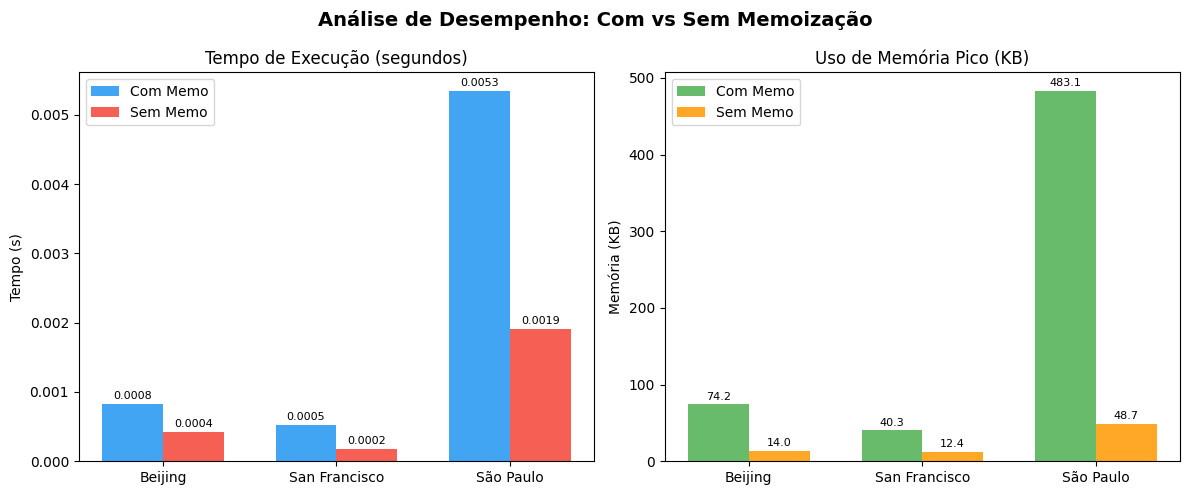

✅ Gráfico salvo em desempenho.png


In [ ]:
# Gráfico de comparação de desempenho
try:
    import matplotlib.pyplot as plt
    import numpy as np

    cidades_labels = [d[0] for d in perf_data]
    t_com_vals = [d[1] for d in perf_data]
    t_sem_vals = [d[3] for d in perf_data]
    m_com_vals = [d[2] for d in perf_data]
    m_sem_vals = [d[4] for d in perf_data]

    x = np.arange(len(cidades_labels))
    w = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Análise de Desempenho: Com vs Sem Memoização', fontsize=14, fontweight='bold')

    bars1 = ax1.bar(x - w/2, t_com_vals, w, label='Com Memo', color='#2196F3', alpha=0.85)
    bars2 = ax1.bar(x + w/2, t_sem_vals, w, label='Sem Memo', color='#F44336', alpha=0.85)
    ax1.set_title('Tempo de Execução (segundos)')
    ax1.set_xticks(x); ax1.set_xticklabels(cidades_labels)
    ax1.set_ylabel('Tempo (s)'); ax1.legend()
    ax1.bar_label(bars1, fmt='%.4f', padding=2, fontsize=8)
    ax1.bar_label(bars2, fmt='%.4f', padding=2, fontsize=8)

    bars3 = ax2.bar(x - w/2, m_com_vals, w, label='Com Memo', color='#4CAF50', alpha=0.85)
    bars4 = ax2.bar(x + w/2, m_sem_vals, w, label='Sem Memo', color='#FF9800', alpha=0.85)
    ax2.set_title('Uso de Memória Pico (KB)')
    ax2.set_xticks(x); ax2.set_xticklabels(cidades_labels)
    ax2.set_ylabel('Memória (KB)'); ax2.legend()
    ax2.bar_label(bars3, fmt='%.1f', padding=2, fontsize=8)
    ax2.bar_label(bars4, fmt='%.1f', padding=2, fontsize=8)

    plt.tight_layout()
    plt.savefig('desempenho.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfico salvo em desempenho.png')
except ImportError:
    print('ℹmatplotlib não disponível — instale com: pip install matplotlib')

---
## [7] Visualização com Folium

Geramos mapas interativos para cada cidade. O grafo completo é exibido em **cinza** e o caminho mais curto encontrado é destacado em **azul**.

In [ ]:
def gerar_mapa(cidade_nome, grafo, coords, orig, dest, caminho_min, caminho_max):
    """
    Gera mapa Folium com:
    - Todas as arestas do grafo em cinza
    - Caminho mais curto em azul
    - Caminho mais longo em laranja
    - Marcadores especiais para origem e destino
    """
    # Centro do mapa
    lats = [v[0] for v in coords.values()]
    lons = [v[1] for v in coords.values()]
    centro = (sum(lats)/len(lats), sum(lons)/len(lons))

    m = folium.Map(location=centro, zoom_start=12,
                   tiles='CartoDB positron')

    # Arestas do grafo
    visitadas = set()
    for est, vizinhos in grafo.items():
        if est not in coords:
            continue
        for viz, peso in vizinhos:
            aresta = tuple(sorted([est, viz]))
            if aresta in visitadas or viz not in coords:
                continue
            visitadas.add(aresta)
            folium.PolyLine(
                [coords[est], coords[viz]],
                color='#999999', weight=2, opacity=0.5,
                tooltip=f'{est} → {viz}: {peso} min'
            ).add_to(m)

    # Caminho mais longo (laranja, abaixo)
    if len(caminho_max) > 1:
        pontos_max = [coords[e] for e in caminho_max if e in coords]
        if len(pontos_max) > 1:
            folium.PolyLine(
                pontos_max, color='#FF6F00', weight=5,
                opacity=0.7, tooltip='Caminho mais longo'
            ).add_to(m)

    # Caminho mais curto (azul, acima)
    if len(caminho_min) > 1:
        pontos_min = [coords[e] for e in caminho_min if e in coords]
        if len(pontos_min) > 1:
            folium.PolyLine(
                pontos_min, color='#1565C0', weight=5,
                opacity=0.9, tooltip='Caminho mais curto'
            ).add_to(m)

    # Marcadores
    for est, (lat, lon) in coords.items():
        if est == orig:
            cor, icone = 'green', 'play'
        elif est == dest:
            cor, icone = 'red', 'stop'
        elif est in caminho_min:
            cor, icone = 'blue', 'train'
        else:
            cor, icone = 'gray', 'circle'

        folium.Marker(
            [lat, lon],
            popup=folium.Popup(est, max_width=200),
            tooltip=est,
            icon=folium.Icon(color=cor, icon=icone, prefix='fa')
        ).add_to(m)

    # Legenda
    legenda = f"""
    <div style='position:fixed; bottom:30px; left:30px; z-index:1000;
                background:white; padding:10px; border-radius:8px;
                border:2px solid #ccc; font-family:Arial; font-size:13px'>
      <b>{cidade_nome}</b><br>
      <span style='color:#1565C0'>━━</span> Caminho mais curto<br>
      <span style='color:#FF6F00'>━━</span> Caminho mais longo<br>
      <span style='color:#999'>━━</span> Rede completa<br>
      🟢 Origem &nbsp; 🔴 Destino
    </div>
    """
    m.get_root().html.add_child(folium.Element(legenda))
    return m


print('Função de mapa definida!')

✅ Função de mapa definida!


In [ ]:
# --- Mapa: São Paulo ---
r_sp = resultados['🇧🇷 São Paulo']
mapa_sp = gerar_mapa(
    'São Paulo — Metrô + CPTM',
    grafo_sp, coords_sp,
    r_sp['orig'], r_sp['dest'],
    r_sp['cam_min'], r_sp['cam_max']
)
mapa_sp.save('mapa_sao_paulo.html')
print('Mapa São Paulo salvo: mapa_sao_paulo.html')
display(mapa_sp)

🗺️  Mapa São Paulo salvo: mapa_sao_paulo.html


In [ ]:
# --- Mapa: Beijing ---
r_bj = resultados['🇨🇳 Beijing']
mapa_bj = gerar_mapa(
    'Beijing — Linhas 1, 2, 4, 10',
    grafo_beijing, coords_beijing,
    r_bj['orig'], r_bj['dest'],
    r_bj['cam_min'], r_bj['cam_max']
)
mapa_bj.save('mapa_beijing.html')
print('Mapa Beijing salvo: mapa_beijing.html')
display(mapa_bj)

🗺️  Mapa Beijing salvo: mapa_beijing.html


In [ ]:
# --- Mapa: San Francisco ---
r_sf = resultados['🇺🇸 San Francisco']
mapa_sf = gerar_mapa(
    'San Francisco — BART',
    grafo_sf, coords_sf,
    r_sf['orig'], r_sf['dest'],
    r_sf['cam_min'], r_sf['cam_max']
)
mapa_sf.save('mapa_sf.html')
print('Mapa San Francisco salvo: mapa_sf.html')
display(mapa_sf)

🗺️  Mapa San Francisco salvo: mapa_sf.html


---
## [8] Análise de Complexidade e Conclusões

### Complexidade Big-O

| Algoritmo | Sem Memoização | Com Memoização |
|---|---|---|
| Caminho Mais Curto | O(V!) | O(2^V × V) |
| Caminho Mais Longo (Backtracking) | O(V!) | N/A (estado depende de visitados) |

A memoização converte o problema de **exponencial fatorial** para **exponencial de 2^V** ao garantir que cada par `(estação, conjunto_visitados)` seja calculado apenas uma vez. Para grafos pequenos (como os modelados neste trabalho, com ~15–40 nós), a diferença de tempo é mensurável; para grafos maiores, a diferença seria ainda mais dramática.

### Por que Grafos Não-Dirigidos?

As três redes de metrô escolhidas operam nos dois sentidos sobre os mesmos trilhos — não há linhas com sentido único obrigatório. A modelagem não-dirigida simplifica a representação sem perda de realidade.

### Sobre Memoização

- **`functools.lru_cache`**: Funciona porque todos os argumentos são **hasháveis** (`frozenset` para o conjunto de visitados).
- O cache elimina chamadas recursivas redundantes: o mesmo subproblema `(estação_X, visitados_Y)` pode aparecer em centenas de ramos diferentes da recursão; com memoização, é calculado uma única vez.
- A troca é **memória por tempo**: o cache usa mais RAM, mas evita recomputação.

### Conclusões

1. **Memoização é essencial** para problemas de caminhos em grafos — sem ela, o tempo explode combinatorialmente.
2. **Fatores de horário** alteram significativamente a rota ótima: no pico da tarde (×2,0), caminhos mais curtos geograficamente podem ter custos maiores que rotas alternativas.
3. **Caminho mais longo** exige backtracking completo e não escala bem para grafos grandes — é NP-difícil no caso geral.
4. As **estações de integração** em São Paulo (Sé, Ana Rosa, Consolação) são gargalos críticos e aparecem tanto no caminho mais curto quanto no mais longo.
